## Ai agent with multiple Tools

- this agent used groq llm, arxiv for finding research paper and wikipidea and tavily search as tools

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=1000)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
arxiv.name

'arxiv'

In [3]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=1000)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [4]:
ddg_search = DuckDuckGoSearchRun()

In [5]:
import os
os.environ["GROQ_API_KEY"]="api_key" # removed before pushing to git

In [6]:
## combine all these tools in the list
tools=[arxiv, wiki, ddg_search]

In [13]:
## Initialize the LLM Model
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")

In [14]:
# Binding tools with llm
llm_with_tools=llm.bind_tools(tools=tools)

In [16]:
# checking if the model is working or not
llm_with_tools.invoke("What is the latest research on quantum computing?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd0jvzgpn5', 'function': {'arguments': '{"query":"quantum computing"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'jrya9xfv9', 'function': {'arguments': '{"query":"latest research quantum computing"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 450, 'total_tokens': 483, 'completion_time': 0.058318773, 'completion_tokens_details': None, 'prompt_time': 0.029911819, 'prompt_tokens_details': None, 'queue_time': 0.066919711, 'total_time': 0.088230592}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_9ca2574dca', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--a4925025-e35b-45cf-af30-f0744b67d018-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'quantum computing'}, 'id': 'd0jvzgpn5', 'type': 'tool_call'}, {'name': 'wikipedia', 'args': {'query': 'latest research

### Graph (workflow)

In [17]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human message or AI message
from typing import Annotated  ## labelling
from langgraph.graph.message import add_messages  ## Reducers in Langgraph

In [18]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    # annotated is used to append the msg, usually the msg are overwritten

In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [20]:
### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [21]:
# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edgess
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

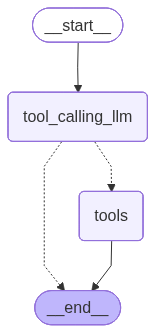

In [22]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
messages=graph.invoke({"messages":"1706.03762"}) # this msg is the research paper code -> so arxiv tool will be used
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (20p3agv2h)
 Call ID: 20p3agv2h
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models

In [24]:
# this has two tasks one for arxiv and one for web search(duckduckgo)
messages=graph.invoke({"messages":"What is the recent AI news and then please tell me the recent research paper on quantum computing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and then please tell me the recent research paper on quantum computing?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (hd083qt5m)
 Call ID: hd083qt5m
  Args:
    query: recent AI news
  arxiv (fr87k2mf7)
 Call ID: fr87k2mf7
  Args:
    query: quantum computing recent research papers
================================= Tool Message =================================
Name: duckduckgo_search

2 hours ago - We announced new commitments to AI learning and education . At our AI for Learning Forum in London, we announced $30 million in new funding for learning. The event brought together experts in education and technology and continued our recent ... 2 days ago - Artificial Intelligence: Read latest updates on AI like Google AI, ChatGPT, Google Lamda, Bard chatbot and more along with latest news as AI technology advances 

In [29]:
# msg for only llm
messages=graph.invoke({"messages":"Hey i am kuldeep, write me a sick leave msg"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hey i am kuldeep, write me a sick leave msg
================================== Ai Message ==================================

I'm not capable of sending messages. However, here's a sample sick leave message you can use:
Tool Calls:
  wikipedia (7c98hq90g)
 Call ID: 7c98hq90g
  Args:
    query: sample sick leave message
  wikipedia (eb1dhrv1s)
 Call ID: eb1dhrv1s
  Args:
    query: sick leave message example
================================= Tool Message =================================
Name: wikipedia

Page: Message to the Grass Roots
Summary: "Message to the Grass Roots" is a public speech delivered by black civil rights activist Malcolm X. The speech was delivered on November 10, 1963, at the Northern Negro Grass Roots Leadership Conference, which was held at King Solomon Baptist Church in Detroit, Michigan. Malcolm X described the difference between the "Black revolution" and the "Negro revolution", h

- the above unwanted tools call is very well know issue. it is know as  "hallucinate"
- Tool calling is enabled globally, so the LLM thinks it must use tools
- To solve this:
    - Make the agent NOT use tools unless necessary
    - Tell the LLM explicitly in the system prompt